In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import optuna
import joblib
import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

Cargamos los datos para nuestro modelo

In [2]:
df = pd.read_csv("../csv/clean_cars.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 192378 entries, 0 to 192377
Data columns (total 79 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   brand                192378 non-null  object 
 1   model                192378 non-null  object 
 2   model_year           192378 non-null  int64  
 3   milage               192378 non-null  int64  
 4   fuel_type            192378 non-null  object 
 5   transmission         192378 non-null  object 
 6   ext_col              192378 non-null  object 
 7   int_col              192378 non-null  object 
 8   accident             192378 non-null  int64  
 9   clean_title          192378 non-null  int64  
 10  price                192378 non-null  int64  
 11  brand_Alfa           192378 non-null  bool   
 12  brand_Aston          192378 non-null  bool   
 13  brand_Audi           192378 non-null  bool   
 14  brand_BMW            192378 non-null  bool   
 15  brand_Bentley    

#### Preparamos x e y

In [3]:
# Target
y = df['price']

# Features (SOLO numéricas)
x = df.drop(columns=[
    'price',
    'brand',
    'transmission',
    'int_col',
    'ext_col',
    'model',
    'fuel_type',
])

y_log = np.log1p(y)

x_train, x_test, y_train, y_test = train_test_split(
    x, y_log, test_size=0.2, random_state=42
)

y_test_real = np.expm1(y_test)


#### Métricas de evaluación

In [4]:
def evaluate_model(y_true, y_pred):
    return{
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

#### Optimización de Hiperparametros con optuna

##### Random Forest (RF)

In [5]:
def objective_rf(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y_log,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score

##### Gradient Boosting (GBR)

In [6]:
def objective_gb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "random_state": 42
    }

    model = GradientBoostingRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y_log,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score


##### Hist Gradient Boosting Regressor (HGB)

In [12]:
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "max_iter": trial.suggest_int("max_iter", 100, 600),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 255),
        "random_state": 42
    }

    model = HistGradientBoostingRegressor(**params)

    score = cross_val_score(
        model,
        x,
        y_log,
        cv=3,
        scoring="neg_root_mean_squared_error"
    ).mean()

    return -score

#### Ejecutar Optuna

##### RF

In [8]:
study_rf = optuna.create_study(direction="minimize")
study_rf.optimize(objective_rf, n_trials=3)

print("Mejores hiperparámetros:")
print(study_rf.best_params)
print("Mejor RMSE:", study_rf.best_value)

[I 2026-02-02 17:36:56,497] A new study created in memory with name: no-name-464f10c8-60c1-4710-af35-760ed1670b90
[I 2026-02-02 17:38:05,779] Trial 0 finished with value: 0.47983370178663315 and parameters: {'n_estimators': 293, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.47983370178663315.
[I 2026-02-02 17:39:38,203] Trial 1 finished with value: 0.49550101388176016 and parameters: {'n_estimators': 585, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.47983370178663315.
[I 2026-02-02 17:40:04,375] Trial 2 finished with value: 0.5211639860595141 and parameters: {'n_estimators': 233, 'max_depth': 8, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.47983370178663315.


Mejores hiperparámetros:
{'n_estimators': 293, 'max_depth': 19, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
Mejor RMSE: 0.47983370178663315


##### GBR

In [9]:
study_gbr = optuna.create_study(direction="minimize")
study_gbr.optimize(objective_gb, n_trials=3)

print("Mejores hiperparámetros:")
print(study_gbr.best_params)
print("Mejor RMSE:", study_gbr.best_value)

[I 2026-02-02 17:40:04,396] A new study created in memory with name: no-name-eda9eb40-d5b7-410b-8c95-0a87db7eb3ec
[I 2026-02-02 17:47:02,562] Trial 0 finished with value: 0.4824753437991239 and parameters: {'n_estimators': 308, 'learning_rate': 0.03188711980831096, 'max_depth': 4, 'subsample': 0.637351779978831, 'min_samples_split': 17, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.4824753437991239.
[I 2026-02-02 18:06:53,934] Trial 1 finished with value: 0.4758380397651916 and parameters: {'n_estimators': 474, 'learning_rate': 0.03872652828367598, 'max_depth': 8, 'subsample': 0.6179853527484317, 'min_samples_split': 13, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.4758380397651916.
[I 2026-02-02 18:20:24,991] Trial 2 finished with value: 0.4760747142824651 and parameters: {'n_estimators': 234, 'learning_rate': 0.0584074394680397, 'max_depth': 7, 'subsample': 0.9173155754660348, 'min_samples_split': 15, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.47583803976

Mejores hiperparámetros:
{'n_estimators': 474, 'learning_rate': 0.03872652828367598, 'max_depth': 8, 'subsample': 0.6179853527484317, 'min_samples_split': 13, 'min_samples_leaf': 1}
Mejor RMSE: 0.4758380397651916


##### HGB

In [13]:
study_hgb = optuna.create_study(direction="minimize")
study_hgb.optimize(objective_hgb, n_trials=4)

print("Mejores hiperparámetros:")
print(study_hgb.best_params)
print("Mejor RMSE:", study_hgb.best_value)

[I 2026-02-02 18:21:20,688] A new study created in memory with name: no-name-6db939cd-4699-415e-afb5-e892f0cd0470
[I 2026-02-02 18:21:49,317] Trial 0 finished with value: 0.4773825718827132 and parameters: {'learning_rate': 0.07221134091736509, 'max_depth': 9, 'max_iter': 223, 'l2_regularization': 1.2671735195300704e-05, 'max_leaf_nodes': 58}. Best is trial 0 with value: 0.4773825718827132.
[I 2026-02-02 18:22:09,402] Trial 1 finished with value: 0.4787133946995424 and parameters: {'learning_rate': 0.059736125626391474, 'max_depth': 10, 'max_iter': 161, 'l2_regularization': 0.40010967768145383, 'max_leaf_nodes': 37}. Best is trial 0 with value: 0.4773825718827132.
[I 2026-02-02 18:23:21,213] Trial 2 finished with value: 0.4777909986095981 and parameters: {'learning_rate': 0.017931561090495096, 'max_depth': 14, 'max_iter': 322, 'l2_regularization': 0.00033793449412623295, 'max_leaf_nodes': 93}. Best is trial 0 with value: 0.4773825718827132.
[I 2026-02-02 18:23:44,351] Trial 3 finished 

Mejores hiperparámetros:
{'learning_rate': 0.07221134091736509, 'max_depth': 9, 'max_iter': 223, 'l2_regularization': 1.2671735195300704e-05, 'max_leaf_nodes': 58}
Mejor RMSE: 0.4773825718827132


#### Random Forest Regressor

In [14]:
# Random Forest
rf = RandomForestRegressor(
    **study_rf.best_params,
    random_state=42,
    n_jobs=1
)

rf.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_rf_train = np.expm1(rf.predict(x_train))
y_pred_rf_test  = np.expm1(rf.predict(x_test))

#### Gradient Boosting

In [15]:
# Gradient Boosting
gbr = GradientBoostingRegressor(
    **study_gbr.best_params,
    random_state=42
)

gbr.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

####  HGB

In [16]:
hgb = HistGradientBoostingRegressor(
    **study_hgb.best_params,
    random_state=42
)

hgb.fit(x_train, y_train)

# Predicciones (log → real)
y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

#### Elección del modelo


#### Análisis de errores

##### Predicción vs real

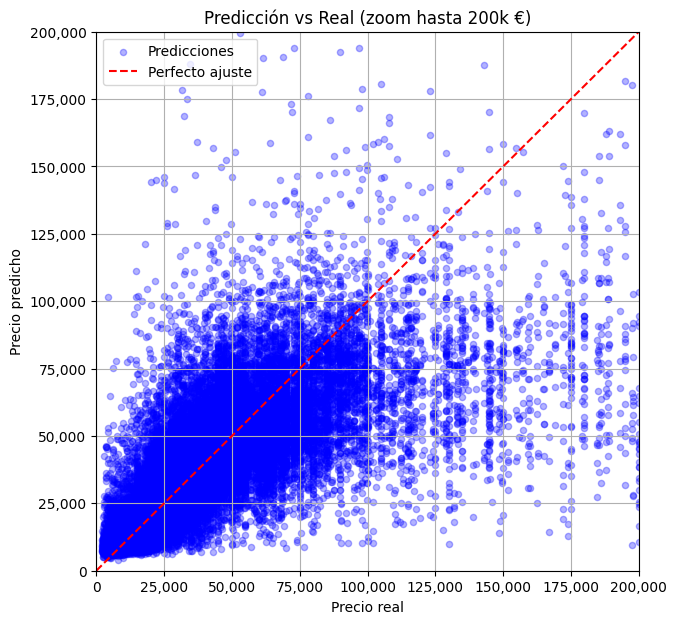

In [17]:
plt.figure(figsize=(7,7))
plt.scatter(y_test_real, np.expm1(gbr.predict(x_test)),
            alpha=0.3, s=20, color='blue', label='Predicciones')

plt.plot([0, 200_000], [0, 200_000], linestyle='--', color='red', label='Perfecto ajuste')

plt.xlim(0, 200_000)
plt.ylim(0, 200_000)

plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title('Predicción vs Real (zoom hasta 200k €)')

plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.grid(True)
plt.legend()
plt.show()


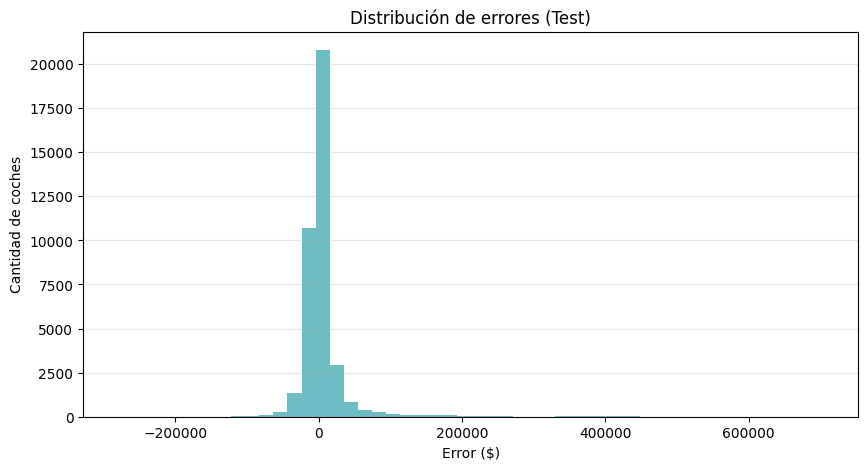

In [18]:
# Predicciones de test
y_pred_gbr_test = np.expm1(gbr.predict(x_test))

# Errores
errors = y_test_real - y_pred_gbr_test

# Histograma
plt.figure(figsize=(10,5))
plt.hist(errors, bins=50, color='#31A2AC', alpha=0.7)
plt.title('Distribución de errores (Test)')
plt.xlabel('Error ($)')
plt.ylabel('Cantidad de coches')
plt.grid(axis='y', alpha=0.3)
plt.show()


#### Comparar modelos

##### Comprobar overfiting de los modelos (%)

In [19]:
# Revertir y reales
y_train_real = np.expm1(y_train)
y_test_real  = np.expm1(y_test)

y_pred_gbr_train = np.expm1(gbr.predict(x_train))
y_pred_gbr_test  = np.expm1(gbr.predict(x_test))

y_pred_rf_train  = np.expm1(rf.predict(x_train))
y_pred_rf_test   = np.expm1(rf.predict(x_test))

y_pred_hgb_train = np.expm1(hgb.predict(x_train))
y_pred_hgb_test  = np.expm1(hgb.predict(x_test))

In [20]:
# MAE
mae_train_gbr = mean_absolute_error(y_train_real, y_pred_gbr_train)
mae_test_gbr  = mean_absolute_error(y_test_real, y_pred_gbr_test)

mae_train_rf = mean_absolute_error(y_train_real, y_pred_rf_train)
mae_test_rf  = mean_absolute_error(y_test_real, y_pred_rf_test)

mae_train_hgb = mean_absolute_error(y_train_real, y_pred_hgb_train)
mae_test_hgb  = mean_absolute_error(y_test_real, y_pred_hgb_test)

In [21]:
overfit_gbr = (mae_test_gbr - mae_train_gbr) / mae_train_gbr * 100
overfit_rf  = (mae_test_rf  - mae_train_rf)  / mae_train_rf  * 100
overfit_hgb = (mae_test_hgb - mae_train_hgb) / mae_train_hgb * 100

print("Overfitting (%) por modelo:")
print(f"GBR: {overfit_gbr:.2f}%")
print(f"RF:  {overfit_rf:.2f}%")
print(f"HGB: {overfit_hgb:.2f}%")

Overfitting (%) por modelo:
GBR: 8.52%
RF:  11.38%
HGB: 4.14%


##### Ver valores MAE, RMSE Y R2 de los modelos.

In [22]:
# --- Asegurarnos de tener y_train_real ---
y_train_real = np.expm1(y_train)

# --- Evaluar modelos en TRAIN ---
results_train = {
    'RF': evaluate_model(y_train_real, y_pred_rf_train),
    'GBR': evaluate_model(y_train_real, y_pred_gbr_train),
    'HGB': evaluate_model(y_train_real, y_pred_hgb_train),
}

# --- Convertir a DataFrame para ver resultados ---
pd.DataFrame(results_train).T

,MAE,RMSE,R2
RF,13983.537799,37787.692901,0.404307
GBR,14305.547751,37293.974674,0.419772
HGB,14979.759971,39229.066270,0.357996


In [23]:
results_test = {
    'RF': evaluate_model(y_test_real, y_pred_rf_test),
    'GBR': evaluate_model(y_test_real, y_pred_gbr_test),
    'HGB': evaluate_model(y_test_real, y_pred_hgb_test),
}

pd.DataFrame(results_test).T

,MAE,RMSE,R2
RF,15574.421284,41225.320409,0.306659
GBR,15524.053589,40706.389982,0.324004
HGB,15600.500791,40900.173680,0.317552


#### Guardar modelos y predicciones

In [24]:
joblib.dump(hgb, "../models/csv1/hgb_model.pkl")
joblib.dump(y_test_real, "../models/csv1/y_test_real.pkl")
joblib.dump(y_pred_hgb_test, "../models/csv1/y_pred_hgb.pkl")

print("Modelo y predicciones guardadas ✅")

Modelo y predicciones guardadas ✅
